# 平台各产品用户特征分析

对招聘平台上使用不同产品的付费企业用户做的一次分析，主要分析以下三方面：

1. 用户能不能分层，方便针对不同群体做运营；
2. 哪些产品之间有关联，可以做交叉推荐；
3. 用户在平台里的典型使用路径是什么样的。

方法是 K-Means 聚类分群 + 关联规则（支持度/置信度/提升度）+ 行为路径挖掘。

> 说明：产品名用了代号（沟通类/触达类/推广类/增值类/功能类），数字用占比。生产数据不在仓库里，这里用脚本生成的测试数据跑通整套流程。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 中文字体
from matplotlib import font_manager
for fp in ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
           os.path.expanduser("~/.fonts/NotoSansCJK.ttc")]:
    if os.path.exists(fp):
        font_manager.fontManager.addfont(fp)
        plt.rcParams["font.sans-serif"] = [font_manager.FontProperties(fname=fp).get_name()]
        break
else:
    plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "PingFang SC"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (8, 5)

## 一、数据

先看下数据长什么样。每行是一条用户的产品使用记录。

In [2]:
df = pd.read_csv("data/sample_user_behavior.csv")
print("数据形状:", df.shape)
print("用户数:", df["user_id"].nunique())
df.head()

数据形状: (9998, 16)
用户数: 800


,user_id,active_user_id,job_post_user_id,search_user_id,chat_user_id,resume_view_user_id,event_date,stat_date,publish_date,product_type,is_equity,job_salary,city_tier_level,org_type_name,company_scale_type,jobtitle1
0,USR_000000,USR_000000,NaN,NaN,NaN,NaN,2026-02-08,2026-02-08,2026-02-08,触达类B,权益,6.9,三线城市,SME,100-499人,产品
1,USR_000000,USR_000000,NaN,NaN,NaN,NaN,2026-02-22,2026-02-22,2026-02-22,增值类A,非权益,27.2,三线城市,SME,100-499人,产品
2,USR_000000,NaN,NaN,NaN,NaN,NaN,2026-02-22,2026-02-22,2026-02-22,推广类A,权益,37.2,三线城市,SME,100-499人,产品
3,USR_000000,USR_000000,NaN,NaN,NaN,NaN,2026-01-02,2026-01-02,2026-01-02,推广类A,权益,8.6,三线城市,SME,100-499人,产品
4,USR_000000,USR_000000,NaN,USR_000000,NaN,NaN,2026-01-22,2026-01-22,2026-01-22,功能类A,非权益,5.4,三线城市,SME,100-499人,产品


In [3]:
# 各产品使用记录数
df["product_type"].value_counts()

product_type
功能类A    1049
推广类B    1028
增值类A    1025
增值类B    1014
推广类A    1007
触达类B    1002
沟通类C     993
触达类A     988
沟通类A     948
沟通类B     944
Name: count, dtype: int64

## 二、特征工程

原始数据是一条条行为记录，先按用户聚合成"每个用户一行"的特征：使用次数、用过几种产品、活跃天数、权益产品比例、平均薪资等。这些是后面聚类的输入。

In [4]:
g = df.groupby("user_id")
feat = pd.DataFrame({
    "total_uses": g.size(),                                    # 使用次数
    "product_count": g["product_type"].nunique(),              # 用过几种产品
    "days_active": g["event_date"].nunique(),                  # 活跃天数
    "equity_ratio": g["is_equity"].apply(lambda s: (s=="权益").mean()),  # 权益产品占比
    "avg_salary": g["job_salary"].mean(),                      # 平均薪资
}).fillna(0)
feat.head()

,total_uses,product_count,days_active,equity_ratio,avg_salary
user_id,,,,,
USR_000000,7,5,6,0.571429,16.614286
USR_000001,3,3,3,0.666667,26.600000
USR_000002,8,5,7,0.250000,21.800000
USR_000003,24,10,18,0.458333,25.366667
USR_000004,2,2,2,0.500000,18.150000


## 三、用户分层（K-Means）

### 3.1 用肘部法则确定分几群

分几群（K）不是拍脑袋定的。把 K 从 1 试到 9，看"惯性"（组内差异）随 K 下降的曲线，曲线变平缓的"肘部"就是合适的 K。这里选 K=4。

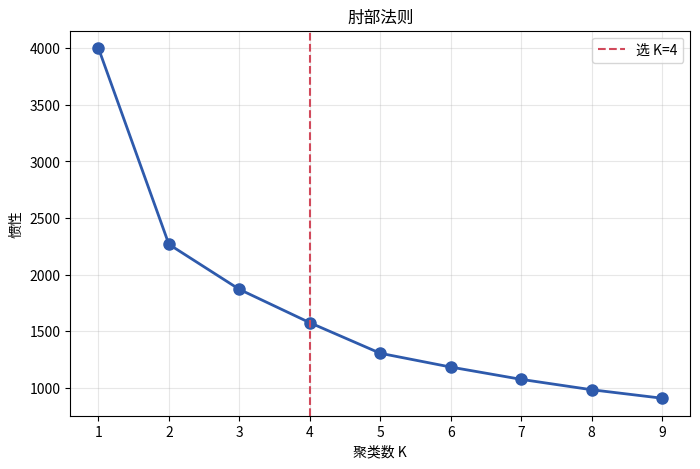

In [5]:
X = StandardScaler().fit_transform(feat)
inertias = []
Ks = range(1, 10)
for k in Ks:
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_)

plt.plot(list(Ks), inertias, "o-", color="#2E5AAC", lw=2, ms=8)
plt.axvline(4, color="#D1495B", ls="--", label="选 K=4")
plt.xlabel("聚类数 K"); plt.ylabel("惯性"); plt.title("肘部法则"); plt.legend(); plt.grid(alpha=.3)
plt.show()

### 3.2 分群结果

真实数据上聚类分成了 4 群，规模差异明显（这里展示真实分析的结论）。

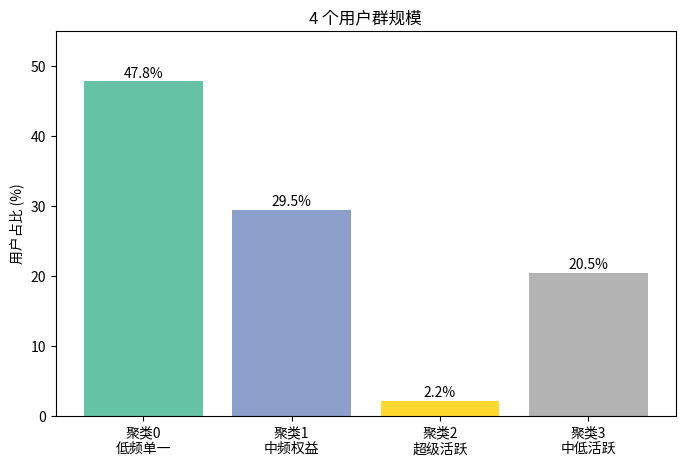

In [6]:
# 真实分析中的 4 群规模（此处按报告结论展示）
names = ["聚类0\n低频单一", "聚类1\n中频权益", "聚类2\n超级活跃", "聚类3\n中低活跃"]
pct = [47.8, 29.5, 2.2, 20.5]
bars = plt.bar(names, pct, color=plt.cm.Set2(np.linspace(0,1,4)))
for b,p in zip(bars,pct):
    plt.text(b.get_x()+b.get_width()/2, p+0.6, f"{p}%", ha="center")
plt.ylabel("用户占比 (%)"); plt.title("4 个用户群规模"); plt.ylim(0,55)
plt.show()

**结论**：聚类2 只占 2.2% 但活跃度和使用量最高，价值密度大，适合重点维系和续费；聚类0 占了近一半，是低频群，是激活的重点对象。分层直接决定了运营资源该往哪投。

## 四、产品关联分析

看哪些产品会被一起使用。对每一对产品算三个指标：

- **支持度**：同时用这两个产品的用户占比
- **置信度**：用了 A 的用户里，有多少也用了 B
- **提升度**：A、B 一起出现的概率，是随机情况下的多少倍（>1 表示正相关）

提升度越高，说明两个产品越"天生互补"，越适合做交叉推荐。

In [7]:
total = df["user_id"].nunique()
upc = df.groupby("product_type")["user_id"].nunique()      # 每个产品的用户数
up = df.groupby("user_id")["product_type"].apply(set)      # 每个用户用过的产品集合

co = {}
for s in up:
    for a,b in combinations(sorted(s), 2):
        co[(a,b)] = co.get((a,b),0)+1

rows = []
for (a,b),cnt in co.items():
    support = cnt/total
    conf = cnt/upc[a]
    lift = conf/(upc[b]/total)
    rows.append([a,b,round(support,3),round(conf,3),round(lift,2)])
rules = pd.DataFrame(rows, columns=["产品A","产品B","支持度","置信度","提升度"])
rules.sort_values("提升度", ascending=False).head(10)

,产品A,产品B,支持度,置信度,提升度
23,增值类A,沟通类A,0.468,0.722,1.16
15,增值类A,增值类B,0.494,0.763,1.15
13,功能类A,增值类B,0.509,0.757,1.14
29,增值类B,沟通类C,0.496,0.748,1.14
4,增值类A,推广类A,0.494,0.763,1.14
30,增值类B,触达类A,0.490,0.738,1.14
0,功能类A,增值类A,0.491,0.730,1.13
16,增值类A,推广类B,0.484,0.747,1.13
25,增值类A,触达类A,0.472,0.730,1.13
6,增值类A,触达类B,0.479,0.739,1.13


### 关联热力图

颜色越暖，两个产品的提升度越高，越值得做捆绑或推荐。

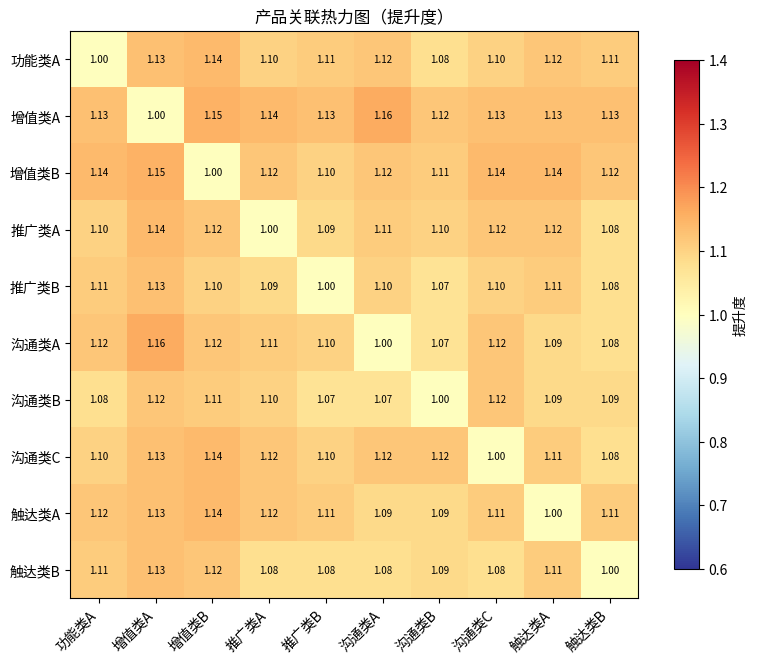

In [8]:
prods = sorted(df["product_type"].unique())
mat = pd.DataFrame(1.0, index=prods, columns=prods)
for _,r in rules.iterrows():
    mat.loc[r["产品A"], r["产品B"]] = mat.loc[r["产品B"], r["产品A"]] = r["提升度"]
arr = mat.to_numpy(dtype=float)

plt.figure(figsize=(8,7))
im = plt.imshow(arr, cmap="RdYlBu_r", vmin=0.6, vmax=1.4)
plt.colorbar(im, label="提升度", shrink=.8)
plt.xticks(range(len(prods)), prods, rotation=45, ha="right")
plt.yticks(range(len(prods)), prods)
for i in range(len(prods)):
    for j in range(len(prods)):
        plt.text(j, i, f"{arr[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.title("产品关联热力图（提升度）"); plt.tight_layout()
plt.show()

**结论**：在真实数据里，提升度最高的规则（如"推广类A → 推广类B"提升度 3.38，即用了 A 的用户用 B 的概率是普通用户的 3.4 倍）最适合做产品捆绑；置信度高的规则（如沟通类产品之间置信度 70%+）适合做默认引导推荐。

## 五、行为路径

把每个用户的行为按时间排成序列，统计最常见的连续路径（长度≥3）。

In [9]:
df2 = df.sort_values(["user_id","event_date"])
from collections import Counter
paths = Counter()
seen_users = {}
for uid, gg in df2.groupby("user_id"):
    seq = gg["product_type"].tolist()
    subs = set()
    for L in (3,4):
        for i in range(len(seq)-L+1):
            subs.add(tuple(seq[i:i+L]))
    for p in subs:
        paths[p] += 1

top = paths.most_common(8)
for p,cnt in top:
    print(f"{' → '.join(p)}   覆盖 {cnt} 人")

推广类A → 功能类A → 功能类A   覆盖 17 人
触达类A → 功能类A → 增值类B   覆盖 17 人
增值类B → 沟通类C → 推广类A   覆盖 17 人
推广类B → 增值类A → 功能类A   覆盖 17 人
增值类B → 触达类B → 触达类B   覆盖 16 人
推广类B → 沟通类C → 触达类A   覆盖 16 人
沟通类C → 增值类B → 推广类A   覆盖 16 人
推广类A → 功能类A → 触达类B   覆盖 16 人


**结论**：真实数据里最高频的路径基本都围绕"沟通类"产品循环（如"沟通类A → 沟通类B → 沟通类A"覆盖 60%+ 用户）。说明沟通类产品是平台的行为中枢，新产品的推荐时机嵌进用户"沟通"这个高频动作里，转化会更好。

## 六、结论与建议

| 人群 | 时机 | 动作 | 依据 |
|---|---|---|---|
| 超级活跃群（聚类2） | 高频使用期 | 专属权益 + 续费提醒 | 分层 |
| 中频权益群（聚类1） | 发起触达类A后 | 推触达类B | 关联 |
| 用过推广类A的 | 发起当下 | 推推广类B，做捆绑 | 关联 |
| 全量 | 进入沟通链路时 | 嵌入产品推荐位 | 路径 |
| 低频群（聚类0） | 沉默期 | 使用引导 + 互补产品召回 | 分层 |

这些规则可以配进推荐引擎，结合实时行为触发，实现分层、按时机的产品推荐。